In [1]:
%matplotlib ipympl

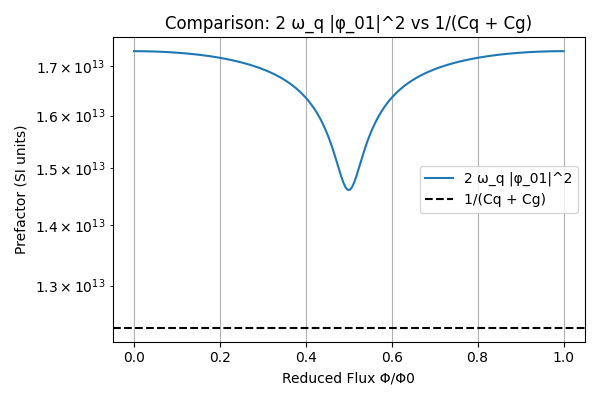

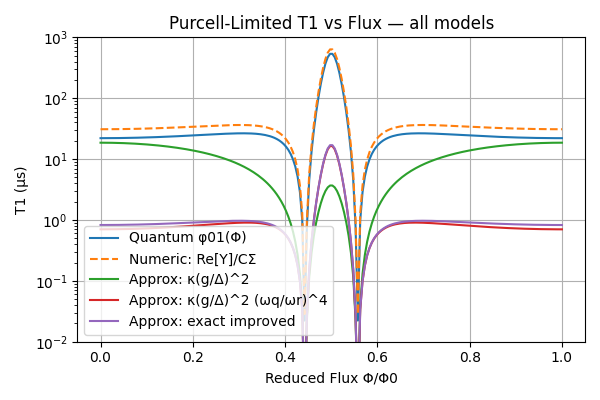

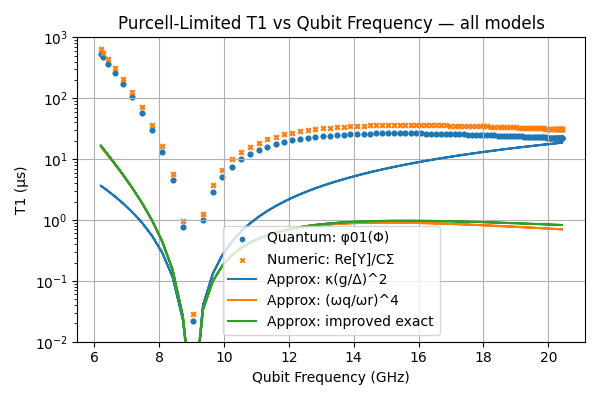

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi


# ======================================================================
#  Physical parameters (same as paper, Appendix A) 
# ======================================================================

# Resonator params
wr = 2 * pi * 9e9          # 7 GHz
kappa = 2 * pi * 12.3e6    # linewidth

# Capacitive couplings
Cg = 1e-15                # 10 fF (example)
Ck = 1e-15                # 10 fF (example)

# Resonator LC values (use wr = 1/sqrt(Lr*(Cr+Ck+Cg)))
# Pick Cr, then compute Lr
Cr = 20e-15               # 20 fF
Ctot_r = Cr + Ck + Cg
Lr = 1 / (wr**2 * Ctot_r)

# 50-ohm feedline
Rfeed = 50.0

# Transmon charging cap (for classical Purcell formula)
Cq = 80e-15                # typical transmon island cap


# ======================================================================
#  Derived quantities
# ======================================================================
def g_of_wq(wq, g0=2*pi*200e6):
    """Frequency-dependent coupling g = g0 * sqrt(wq/wr)."""
    return g0 * np.sqrt(wq / wr)


# =========================================================================
#  Exact circuit numerical Yin(ω) corresponding to Fig. 5(b)
# =========================================================================
def Yin_numeric(wq):
    """
    Compute input admittance seen from the qubit side:
    Qubit -- Cq || [ Cg -- (Lr||Cr) -- Ck -- 50Ω ]
    """

    jw = 1j * wq

    # Your working expression (do NOT touch)
    return jw * Cq + 1/(  1/(jw*Cg) + 1/( jw*Cr + 1/(jw*Lr) + 1/(Rfeed + 1/(jw*Ck)) ) )


# =========================================================================
#  Analytic Purcell formulas (Appendix A)
# =========================================================================
def Gamma_standard(wq):
    Delta = wq - wr
    g = g_of_wq(wq)
    return kappa * (g/Delta)**2

def Gamma_exact(wq):
    Delta = wq - wr
    g = g_of_wq(wq)
    return kappa*(g/Delta)**2 * (wq/wr)**3 * (2*wq/(wq+wr))**2

def Gamma_approx(wq):
    Delta = wq - wr
    g = g_of_wq(wq)
    return kappa*(g/Delta)**2 * (wq/wr)**4


# =========================================================================
#  Numerical Purcell via admittance (Appendix A, Eq. A21)
# =========================================================================
def Gamma_numeric(wq):
    Yin = Yin_numeric(wq)
    return np.real(Yin) / (Cq + Cg)







# =========================================================================
#  NEW PART: scqubits integration – ωq(Φ), φ01(Φ), and quantum Γ
# =========================================================================
try:
    import scqubits as scq
    from scipy.constants import hbar, e


    

    # --- Transmon parameters for TunableTransmon (example) ---
    EJmax_GHz = 150.0     # EJ_max / h in GHz (set to your device)
    EC_GHz    = 0.36     # EC / h in GHz
    d         = 0.1      # EJ asymmetry
    ncut      = 30
    dim_tr    = 6        # truncated Hilbert dimension

    def transmon_freq_and_phi01(flux):
        """
        Use scqubits TunableTransmon to get:
        - ωq(Φ) from 0→1 transition
        - approximate φ_01(Φ) via sin(phi) operator (small-phase limit)
        """
        qubit = scq.TunableTransmon(
            EJmax=EJmax_GHz,
            EC=EC_GHz,
            ng=0.0,
            d=d,
            ncut=ncut,
            truncated_dim=dim_tr,
            flux=flux,
        )
        evals, evecs = qubit.eigensys(evals_count=2)
        # evals in GHz; convert to angular frequency
        w01 = 2 * pi * (evals[1] - evals[0]) * 1e9

        # Use sin(phi) operator; in small-phase regime sin φ ≈ φ
        sinphi = qubit.sin_phi_operator()        # matrix in charge basis
        sinphi01 = (evecs[:, 0].conj().T @ sinphi @ evecs[:, 1]).item()
        phi01 = sinphi01  # dimensionless φ_01 ≈ <0|sin φ|1>

        return w01, phi01

    # Sweep flux using scqubits model
    phi_list_scq = np.linspace(0.0, 1.0, 200)
    wq_flux_scq  = np.zeros_like(phi_list_scq)
    phi01_list   = np.zeros_like(phi_list_scq, dtype=complex)

    for i, phi in enumerate(phi_list_scq):
        wq_flux_scq[i], phi01_list[i] = transmon_freq_and_phi01(phi)
        phi01_list[i] = phi01_list[i]


    Gamma_std_flux = np.array([Gamma_standard(w) for w in wq_flux_scq])
    Gamma_ex_flux  = np.array([Gamma_exact(w)    for w in wq_flux_scq])
    Gamma_ap_flux  = np.array([Gamma_approx(w)   for w in wq_flux_scq])
    T1_std_flux = 1 / Gamma_std_flux
    T1_ex_flux  = 1 / Gamma_ex_flux
    T1_ap_flux  = 1 / Gamma_ap_flux
    T1_class_scq = 1.0 / np.array([Gamma_numeric(w) for w in wq_flux_scq])



    # Environment admittance (subtract qubit capacitor)
    def Yin_env(wq):
        Yin = Yin_numeric(wq)
        jw = 1j * wq
        return Yin - jw * Cq

    # Quantum Purcell rate using φ01(Φ):
    # Γ_φ = 2 ω_q |φ_01|^2 Re[Y_env(ω_q)]
    prefactor = hbar / (4 * e**2)  # ~1.0e3 in SI units (Ohms)

    Gamma_phi_flux = np.array([
        prefactor * 2 * wq_flux_scq[i] * (np.abs(phi01_list[i])**2) *
        np.real(Yin_env(wq_flux_scq[i]))
        for i in range(len(phi_list_scq))
    ])

    T1_phi_flux = 1.0 / Gamma_phi_flux

    # --- Consistency check: 2 ω_q |φ_01|^2 vs 1/(Cq + Cg) ---
    two_w_phi2 = prefactor * 2 * wq_flux_scq * np.abs(phi01_list)**2
    classical_pref = 1.0 / (Cq + Cg)  # constant

    plt.figure(figsize=(6,4))
    plt.plot(phi_list_scq, two_w_phi2, label="2 ω_q |φ_01|^2")
    plt.axhline(classical_pref, color='k', linestyle='--',
                label="1/(Cq + Cg)")
    plt.yscale("log")
    plt.xlabel("Reduced Flux Φ/Φ0")
    plt.ylabel("Prefactor (SI units)")
    plt.title("Comparison: 2 ω_q |φ_01|^2 vs 1/(Cq + Cg)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Plot T1 vs flux, now with scqubits ωq(Φ) + φ01(Φ) ---
    plt.figure(figsize=(6,4))

    plt.plot(phi_list_scq, T1_phi_flux*1e6, label="Quantum φ01(Φ)")
    plt.plot(phi_list_scq, T1_class_scq*1e6, '--', label="Numeric: Re[Y]/CΣ")

    # ADD analytic approximations
    plt.plot(phi_list_scq, T1_std_flux*1e6,  label="Approx: κ(g/Δ)^2")
    plt.plot(phi_list_scq, T1_ap_flux*1e6,   label="Approx: κ(g/Δ)^2 (ωq/ωr)^4")
    plt.plot(phi_list_scq, T1_ex_flux*1e6,   label="Approx: exact improved")

    plt.xlabel("Reduced Flux Φ/Φ0")
    plt.ylabel("T1 (µs)")
    plt.title("Purcell-Limited T1 vs Flux — all models")
    plt.ylim(1e-2, 1e3)
    plt.yscale("log")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


    # --- T1 vs qubit frequency, quantum vs classical + approximations ---
    plt.figure(figsize=(6,4))

    plt.scatter(wq_flux_scq/(2*pi*1e9), T1_phi_flux*1e6,
                s=10, label="Quantum: φ01(Φ)")
    plt.scatter(wq_flux_scq/(2*pi*1e9), T1_class_scq*1e6,
                s=10, marker='x', label="Numeric: Re[Y]/CΣ")

    # ADD analytic approximations
    plt.plot(wq_flux_scq/(2*pi*1e9), T1_std_flux*1e6,  label="Approx: κ(g/Δ)^2")
    plt.plot(wq_flux_scq/(2*pi*1e9), T1_ap_flux*1e6,   label="Approx: (ωq/ωr)^4")
    plt.plot(wq_flux_scq/(2*pi*1e9), T1_ex_flux*1e6,   label="Approx: improved exact")

    plt.xlabel("Qubit Frequency (GHz)")
    plt.ylabel("T1 (µs)")
    plt.title("Purcell-Limited T1 vs Qubit Frequency — all models")
    plt.ylim(1e-2, 1e3)
    plt.yscale("log")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


except ImportError:
    print("scqubits not installed; skipping transmon integration.")


In [3]:
def Y_qubit(w, wq, phi01, gamma=2e6):
    # gamma = intrinsic qubit linewidth (rad/s)
    # prefactor = 2 w |phi01|^2 ħ/(4e^2) – but in admittance SI units:
    from scipy.constants import hbar, e
    prefac = (hbar / (4*e**2)) * 2 * w * (np.abs(phi01)**2)
    return prefac / ( (wq - w) - 1j*gamma/2 )





In [4]:
# import numpy as np
# import scipy.constants as const
# import matplotlib.pyplot as plt

# # ======================================================================
# # 0. PHYSICAL CONSTANTS
# # ======================================================================

# h = const.h
# e = const.e
# Phi0 = h / (2 * e)      # Flux quantum [Wb]
# pi = np.pi

# # ======================================================================
# # 1. SQUID / QUBIT PARAMETERS
# # ======================================================================

# def squid_EJ_eff(EJ, d, Phi_ext):
#     """
#     Effective EJ of an asymmetric SQUID at external flux Phi_ext.

#     Parameters
#     ----------
#     EJ : float
#         Average Josephson energy of each junction [J].
#     d : float
#         Asymmetry parameter (0..1). EJ1 = EJ(1+d), EJ2 = EJ(1-d).
#     Phi_ext : float or array
#         External flux through the SQUID loop [Wb].
#     """
#     EJ1 = EJ * (1 + d)
#     EJ2 = EJ * (1 - d)
#     return np.sqrt(EJ1**2 + EJ2**2 + 2 * EJ1 * EJ2 * np.cos(2 * pi * Phi_ext / Phi0))


# def squid_LJ(EJ_eff):
#     """Linearized Josephson inductance LJ from EJ."""
#     return Phi0**2 / (4 * pi**2 * EJ_eff)


# def squid_plasma_frequency(EJ_eff, Cq):
#     """
#     Bare plasma frequency (small oscillations) of the SQUID-based transmon.

#     Parameters
#     ----------
#     EJ_eff : float or array
#         Effective EJ(Φ) [J].
#     Cq : float
#         Total qubit capacitance [F].

#     Returns
#     -------
#     wq : ndarray
#         Angular frequency of the qubit [rad/s].
#     """
#     Lj = squid_LJ(EJ_eff)
#     return 1.0 / np.sqrt(Lj * Cq)


# # ======================================================================
# # 2. ENVIRONMENT: DISCRETIZED JJ CHAIN
# # ======================================================================

# def Y_feedline(w, Cc, R):
#     """
#     Effective admittance seen at the chain end due to a coupling capacitor Cc
#     in series with a semi-infinite 50 Ohm line (modeled as a resistor R).

#     Geometry:
#         node0 -- Cc -- (port node, shunted by R to ground)

#     Exact result (no weak-coupling approximation):
#         Re Y = Cc^2 * R * w^2 / (1 + (Cc*R*w)^2)
#         Im Y = Cc * w / (1 + (Cc*R*w)^2)
#     """
#     x = Cc * R * w
#     return (Cc**2 * R * w**2 + 1j * Cc * w) / (1.0 + x**2)


# def build_chain_admittance_matrix(N, L_sec, C_sec, Cg, Cc, R, w,
#                                   break_middle=True):
#     """
#     Build the nodal admittance matrix Y(ω) of a discrete JJ chain.

#     Geometry (1D chain):
#         node 0 --[L||C]-- node 1 --[L||C]-- ... -- node N

#     - Each node k has a shunt Cg to ground.
#     - Node 0 is additionally coupled to a 50Ω feedline via Cc.
#     - Optionally, the link between the "middle" nodes is removed (to host the qubit):
#           middle bond j_mid between nodes (j_mid, j_mid+1).

#     Parameters
#     ----------
#     N : int
#         Number of LC sections; there are N+1 nodes labelled 0..N.
#     L_sec : float
#         Inductance per section [H].
#     C_sec : float
#         Capacitance per section [F].
#     Cg : float
#         Shunt capacitance to ground at each node [F].
#     Cc : float
#         Coupling capacitor to feedline, connected at node 0 [F].
#     R : float
#         Characteristic impedance of the feedline [Ohm].
#     w : float
#         Angular frequency [rad/s].
#     break_middle : bool
#         If True, the central LC branch is removed to create two terminals
#         for the qubit in the middle of the chain.

#     Returns
#     -------
#     Y : (N+1, N+1) complex ndarray
#         Nodal admittance matrix at frequency ω.
#     mid_left, mid_right : int
#         Indices of the two middle nodes where the qubit connects.
#     """
#     n_nodes = N + 1
#     Y = np.zeros((n_nodes, n_nodes), dtype=complex)

#     # Admittance of one (L || C) section between neighboring nodes
#     Y_sec = 1j * w * C_sec + 1.0 / (1j * w * L_sec)

#     # Middle bond index (between nodes j_mid, j_mid+1)
#     j_mid = N // 2
#     mid_left = j_mid
#     mid_right = j_mid + 1

#     # 1) LC branches between nodes (except the broken middle bond)
#     for j in range(N):
#         if break_middle and j == j_mid:
#             continue  # reserve this branch for the qubit
#         i1, i2 = j, j + 1
#         Y[i1, i1] += Y_sec
#         Y[i2, i2] += Y_sec
#         Y[i1, i2] -= Y_sec
#         Y[i2, i1] -= Y_sec

#     # 2) Shunt Cg to ground at each node
#     Y_shunt = 1j * w * Cg
#     for k in range(n_nodes):
#         Y[k, k] += Y_shunt

#     # 3) Coupling to 50-ohm feedline at node 0 via Cc
#     if Cc is not None and R is not None and Cc > 0.0 and R > 0.0:
#         Y[0, 0] += Y_feedline(w, Cc, R)

#     return Y, mid_left, mid_right


# def Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w):
#     """
#     Environment admittance seen between the two middle nodes where the qubit sits.

#     Quasi-2-port definition:
#       - Remove the qubit (open circuit).
#       - Inject +I into mid_left and -I into mid_right.
#       - Solve Y(ω) V = I.
#       - Z_env(ω) = (V_left - V_right) / I,  with I = 1 A.
#       - Y_env(ω) = 1 / Z_env(ω).

#     Returns
#     -------
#     Y_env : complex
#         Environment admittance between the two qubit terminals [S].
#     """
#     Y, mid_left, mid_right = build_chain_admittance_matrix(
#         N, L_sec, C_sec, Cg, Cc, R, w, break_middle=True
#     )

#     n_nodes = Y.shape[0]

#     # Inject +1 A at mid_left and -1 A at mid_right
#     I_vec = np.zeros(n_nodes, dtype=complex)
#     I_vec[mid_left] = 1.0
#     I_vec[mid_right] = -1.0

#     # Solve Y * V = I
#     V = np.linalg.solve(Y, I_vec)

#     Z_env = (V[mid_left] - V[mid_right])  # since I=1 A
#     Y_env = 1.0 / Z_env
#     return Y_env


# def Y_env_spectrum(N, L_sec, C_sec, Cg, Cc, R, freqs):
#     """
#     Convenience wrapper: compute Y_env(ω) on a frequency grid.

#     Parameters
#     ----------
#     freqs : array
#         Frequencies in Hz.

#     Returns
#     -------
#     Y_env : ndarray of complex
#         Environment admittance per frequency.
#     """
#     Y_list = []
#     for f in freqs:
#         w = 2 * pi * f
#         Y_list.append(Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w))
#     return np.array(Y_list)


# # ======================================================================
# # 3. PURCELL RATE FROM ENVIRONMENT ADMITTANCE
# # ======================================================================

# def purcell_rate_from_admittance(omega_q, Cq, Y_env):
#     """
#     Purcell-like decay rate for a *linear* qubit mode with capacitance Cq
#     shunted by an environment admittance Y_env(ω_q) in parallel.

#     For a parallel RLC-like oscillator weakly damped by Y_env(ω_q):
#         alpha = Re[Y_env(ω_q)] / (2 Cq)  (damping rate of voltage)
#         T1    = 1 / alpha = 2 Cq / Re[Y_env(ω_q)]

#     Parameters
#     ----------
#     omega_q : float
#         Qubit angular frequency [rad/s].
#     Cq : float
#         Total qubit capacitance [F].
#     Y_env : complex
#         Environment admittance evaluated at ω_q [S].

#     Returns
#     -------
#     Gamma : float
#         Purcell decay rate [1/s].
#     T1 : float
#         Purcell-limited lifetime [s].
#     """
#     ReY = np.real(Y_env)
#     if ReY <= 0:
#         return 0.0, np.inf
#     Gamma = ReY / (2.0 * Cq)
#     T1 = 1.0 / Gamma
#     return Gamma, T1


# # ======================================================================
# # 4. MAIN EXAMPLE: JJ CHAIN + SQUID QUBIT IN THE MIDDLE
# # ======================================================================

# if __name__ == "__main__":
#     # --------------------------------------------------------------
#     # Choose *fresh* parameters (adjust as needed)
#     # --------------------------------------------------------------
#     N = 120                 # number of LC sections (→ N+1 islands)
#     L_sec = 0.8e-9          # section inductance [H]
#     C_sec = 60e-15          # section capacitance between islands [F]
#     Cg = 5e-18              # shunt to ground per island [F]

#     R_line = 50.0           # feedline impedance [Ohm]
#     Cc = 2.0e-15            # coupling capacitor to feedline [F]

#     # Qubit total capacitance (shunting the SQUID's Josephson inductance)
#     Cq = 40e-15             # [F] -- transmon-like

#     # SQUID / transmon Josephson energy at zero flux (in Joules)
#     EJ_over_h_GHz = 25.0    # EJ/h in GHz
#     EJ = EJ_over_h_GHz * 1e9 * h
#     d = 0.1                 # SQUID asymmetry

#     # Flux range for the SQUID (0..0.5 Phi0)
#     n_flux = 201
#     Phi_ext_list = np.linspace(0.0, 0.5 * Phi0, n_flux)  # 0 → 0.5 Φ0

#     # Frequency span for admittance spectrum plots
#     f_min = 1e9
#     f_max = 40e9
#     n_f = 1500
#     f_span = np.linspace(f_min, f_max, n_f)

#     # --------------------------------------------------------------
#     # 4.1 Environment admittance spectrum (no qubit inserted)
#     # --------------------------------------------------------------
#     print("Computing Y_env(f) on a dense frequency grid...")
#     Y_env_span = Y_env_spectrum(N, L_sec, C_sec, Cg, Cc, R_line, f_span)

#     # Plot |Y_env| and Re[Y_env]
#     plt.figure(figsize=(7, 5))
#     plt.subplot(2, 1, 1)
#     plt.semilogy(f_span * 1e-9, np.abs(Y_env_span))
#     plt.xlabel("Frequency [GHz]")
#     plt.ylabel("|Y_env(ω)| [S]")
#     plt.title("Environment admittance magnitude seen by SQUID")

#     plt.subplot(2, 1, 2)
#     plt.plot(f_span * 1e-9, np.real(Y_env_span))
#     plt.xlabel("Frequency [GHz]")
#     plt.ylabel("Re Y_env(ω) [S]")
#     plt.yscale("log")
#     plt.tight_layout()
#     plt.show()

#     # --------------------------------------------------------------
#     # 4.2 Qubit frequency vs flux and Purcell T1(Φ)
#     # --------------------------------------------------------------
#     print("Computing qubit frequency and Purcell T1 vs flux...")

#     EJ_eff_list = squid_EJ_eff(EJ, d, Phi_ext_list)
#     wq_list = squid_plasma_frequency(EJ_eff_list, Cq)         # [rad/s]
#     fq_list = wq_list / (2 * pi)                              # [Hz]

#     Gamma_list = np.zeros_like(fq_list)
#     T1_list = np.zeros_like(fq_list)

#     for idx, (fq, wq) in enumerate(zip(fq_list, wq_list)):
#         Y_env_q = Y_env_between_middle_nodes(
#             N, L_sec, C_sec, Cg, Cc, R_line, wq
#         )
#         Gamma, T1 = purcell_rate_from_admittance(wq, Cq, Y_env_q)
#         Gamma_list[idx] = Gamma
#         T1_list[idx] = T1

#     # Print some basic info
#     print("Qubit frequency range: %.2f–%.2f GHz" %
#           (fq_list.min() * 1e-9, fq_list.max() * 1e-9))
#     print("Min / max Purcell T1 over flux: %.2e s – %.2e s" %
#           (np.nanmin(T1_list), np.nanmax(T1_list)))

#     # Flux axis in units of Phi0
#     phi_ext_over_Phi0 = Phi_ext_list / Phi0

#     # Plot f_q(Φ) and T1(Φ)
#     fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

#     ax[0].plot(phi_ext_over_Phi0, fq_list * 1e-9)
#     ax[0].set_ylabel("f_q(Φ) [GHz]")
#     ax[0].set_title("SQUID qubit frequency and Purcell T1 vs flux")

#     ax[1].semilogy(phi_ext_over_Phi0, T1_list)
#     ax[1].set_xlabel("Φ_ext / Φ0")
#     ax[1].set_ylabel("T1^Purcell(Φ) [s]")

#     plt.tight_layout()
#     plt.show()


In [5]:
%matplotlib ipympl

In [6]:
import numpy as np
import scipy.constants as const

import scqubits as scq
hbar = const.hbar


# 1. Define physical constants and conversion factors
h = const.h                      # Planck constant in J*s
e = const.e                      # Elementary charge in C
Phi0 = h / (2 * e)               # Magnetic flux quantum in Wb
GHz = 1e9                        # Conversion for Hz to GHz
fF_to_F = 1e-15                  # femtoFarad to Farad

# 2. Define input parameters
fp_target_GHz = 30          # Target plasma frequency in GHz
wp_target = 2 * np.pi * fp_target_GHz * GHz # Target angular frequency in rad/s

# Junction dimensions
W_um = 0.6                       # Width in um (200 nm)
L_um = 2.0                       # Length in um
N = 120                 # number of cells
# for N in [120]:

C_area_fF_per_um2 = 45.0         # Capacitance per unit area in fF/um^2 (Assumed)

# 3. Calculate Junction Capacitance (C_J)
Area_um2 = W_um * L_um
CJ = C_area_fF_per_um2 * Area_um2 * fF_to_F # Junction capacitance C in Farads (F)

# 4. Calculate Josephson Inductance (L_J)
# Formula: wp = 1/sqrt(LJ * CJ) => LJ = 1 / (wp^2 * CJ)
LJ = 1.0 / (wp_target**2 * CJ)  # Josephson Inductance L in Henries (H)

# 5. Calculate Josephson Energy (E_J)
# Formula: EJ = (Phi0 / (2*pi))^2 / LJ
EJ = (Phi0 / (2 * np.pi))**2 / LJ # Josephson Energy EJ in Joules (J)
EJ_GHz = EJ / h  / GHz                # Josephson Energy EJ in GHz

# 6. Calculate Charging Energy (E_C)
# Formula: EC = e^2 / (2 * (2 * CJ))
EC = e**2 / (2 * CJ)             # Charging Energy EC in Joules (J)
EC_GHz = EC / h  / GHz                  # Charging Energy EC in GHz


# Cg_over_CJ = 0.10       # stray-to-ground ratio
Cg = 20e-18 ###Cg_over_CJ * CJ

# --- Chain design targets (edit here) ---
a = W_um * 1e-6                # cell pitch [m] (for bookkeeping; not critical here)


#########################################
R = 50.0                       # target wave impedance [Ohm]
d = 0.1

Phi_ext = 0.5*Phi0


Cc = 1.5e-15             # [F]

N_SQUID = N // 2


Computing matrix-chain modes (plain)...
Computing matrix-chain modes (with SQUID)...


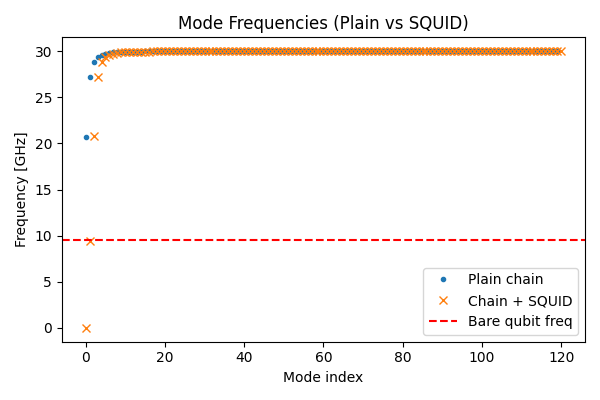

Computing Y_env(f)...


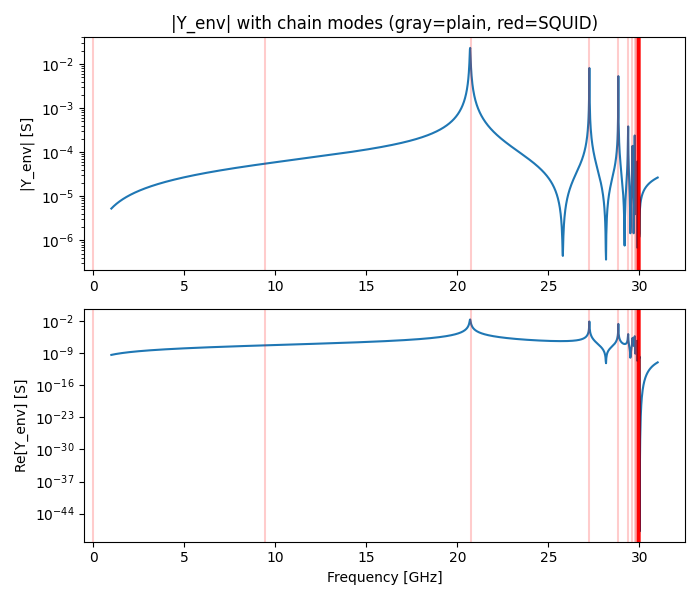

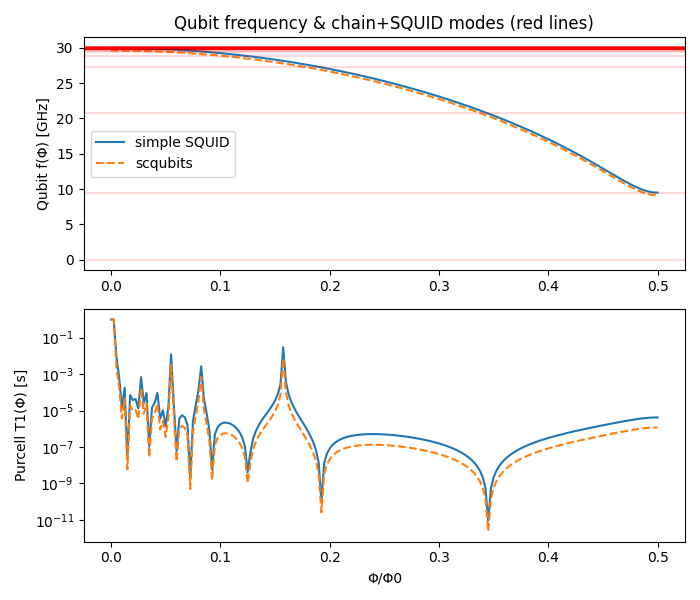

In [7]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
from numpy.linalg import inv, eig

# ======================================================================
# 0. CONSTANTS
# ======================================================================

h = const.h
e = const.e
pi = np.pi
Phi0 = h / (2 * e)   # flux quantum [Wb]


# ======================================================================
# 1. SQUID + TRANSMON BASICS  (USED FOR PURCELL, NOT FOR MATRIX MODES)
# ======================================================================

def squid_EJ_eff(EJ, d, Phi_ext):
    EJ1 = EJ * (1 + d)
    EJ2 = EJ * (1 - d)
    return np.sqrt(EJ1**2 + EJ2**2 + 2 * EJ1 * EJ2 * np.cos(2*pi*Phi_ext/Phi0))

def squid_LJ(EJ_eff):
    return Phi0**2 / (4 * pi**2 * EJ_eff)

def squid_plasma_freq(EJ_eff, Cq):
    Lj = squid_LJ(EJ_eff)
    return 1.0 / np.sqrt(Lj * Cq)       # [rad/s]


# ======================================================================
# 2. ENVIRONMENT ADMITTANCE (CORRECT NEW MODEL)
# ======================================================================

def Y_feedline(w, Cc, R):
    x = Cc * R * w
    return (Cc**2 * R * w**2 + 1j * Cc * w) / (1 + x**2)

def build_chain_admittance_matrix(N, L_sec, C_sec, Cg, Cc, R, w,
                                  break_middle=True):
    n_nodes = N + 1
    Y = np.zeros((n_nodes, n_nodes), dtype=complex)

    Y_sec = 1j*w*C_sec + 1/(1j*w*L_sec)
    j_mid = N//2
    mid_left, mid_right = j_mid, j_mid + 1

    # LC branches except the middle one (reserved for qubit)
    for j in range(N):
        if break_middle and j == j_mid:
            # Y[i1,i1] += 1j*w*C_sec
            # Y[i2,i2] += 1j*w*C_sec
            # Y[i1,i2] -= 1j*w*C_sec
            # Y[i2,i1] -= 1j*w*C_sec
            continue
        i1, i2 = j, j+1
        Y[i1,i1] += Y_sec
        Y[i2,i2] += Y_sec
        Y[i1,i2] -= Y_sec
        Y[i2,i1] -= Y_sec

    # shunt Cg
    Y_shunt = 1j*w*Cg
    for k in range(n_nodes):
        Y[k,k] += Y_shunt

    # feedline coupling at node 0
    if Cc > 0:
        Y[0,0] += Y_feedline(w, Cc, R)

    return Y, mid_left, mid_right

def Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w):
    Ymat, iL, iR = build_chain_admittance_matrix(N, L_sec, C_sec, Cg, Cc, R, w)
    n = Ymat.shape[0]
    I = np.zeros(n, dtype=complex)
    I[iL] = 1
    I[iR] = -1
    V = np.linalg.solve(Ymat, I)
    Zenv = V[iL] - V[iR]
    return 1/Zenv

def Y_env_spectrum(N, L_sec, C_sec, Cg, Cc, R, freqs):
    out = []
    for f in freqs:
        w = 2*pi*f
        out.append(Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w))
    return np.array(out)


# ======================================================================
# 3. PURCELL T1 USING Y_env
# ======================================================================


def transmon_freq_and_phi01(qubit_params, flux):
    """
    Use scqubits TunableTransmon to get:
    - ωq(Φ) from 0→1 transition
    - approximate φ_01(Φ) via sin(phi) operator (small-phase limit)
    """
    qubit = scq.TunableTransmon(
        EJmax=qubit_params['EJ_GHz'],
        EC=qubit_params['EC_GHz'],
        ng=qubit_params['ng'],
        d=qubit_params['d'],
        ncut=qubit_params['ncut'],
        truncated_dim=qubit_params['truncated_dim'],
        flux=flux/Phi0,
    )
    evals, evecs = qubit.eigensys(evals_count=2)
    # evals in GHz; convert to angular frequency
    w01 = 2 * pi * (evals[1] - evals[0]) * 1e9

    # Use sin(phi) operator; in small-phase regime sin φ ≈ φ
    sinphi = qubit.sin_phi_operator()        # matrix in charge basis
    sinphi01 = (evecs[:, 0].conj().T @ sinphi @ evecs[:, 1]).item()
    phi01 = sinphi01  # dimensionless φ_01 ≈ <0|sin φ|1>

    return w01, phi01


def purcell_gamma_T1(CJ, Cq, Yenv):
    ReY = np.real(Yenv)
    if ReY <= 0:
        return 0.0, np.inf
    Gamma = ReY / (2*CJ+Cq)
    return Gamma, 1/Gamma


def purcell_gamma_T1_qub(omega_q, phi01, Yenv):

    prefactor = hbar / (4 * e**2)  # ~1.0e3 in SI units (Ohms)   

    ReY = np.real(Yenv)
    if ReY <= 0:
        return 0.0, np.inf
    Gamma = prefactor * 2 * omega_q * (np.abs(phi01)**2) * ReY
    return Gamma, 1/Gamma

# ======================================================================
# 4. ORIGINAL MATRIX-CHAIN MODEL (FOR MODE SPECTRA ONLY)
# ======================================================================

def build_chain_plain(N, LJ, CJ, Cg, Cc, R):
    n = N + 2
    K = np.zeros((n,n))
    C = np.zeros((n,n))
    G = np.zeros((n,n))

    # JJ inductors & capacitors
    for j in range(1, N+1):
        i1, i2 = j, j+1
        valL = 1/LJ
        K[i1,i1] += valL; K[i2,i2] += valL
        K[i1,i2] -= valL; K[i2,i1] -= valL

        C[i1,i1] += CJ; C[i2,i2] += CJ
        C[i1,i2] -= CJ; C[i2,i1] -= CJ

    # shunt Cg
    for k in range(2, N+2):
        C[k,k] += Cg

    # port Cc
    C[0,0] += Cc; C[1,1] += Cc
    C[0,1] -= Cc; C[1,0] -= Cc

    G[0,0] = 1/R
    return K,C,G


def build_chain_squid(N, LJ, CJ, Cg, Cc, R, EJ, d, Phi_ext, N_SQ=None):
    if N_SQ is None:
        N_SQ = N//2

    EJ_eff = squid_EJ_eff(EJ, d, Phi_ext)
    LJ_s = squid_LJ(EJ_eff)
    CJ_s = 2*CJ

    n = N + 2
    K = np.zeros((n,n))
    C = np.zeros((n,n))
    G = np.zeros((n,n))

    # inductors & capacitors, but one replaced by SQUID
    for j in range(1,N+1):
        i1,i2 = j, j+1
        if j == N_SQ:
            valL = 1/LJ_s
            CJ_eff = CJ_s
        else:
            valL = 1/LJ
            CJ_eff = CJ

        K[i1,i1]+=valL; K[i2,i2]+=valL
        K[i1,i2]-=valL; K[i2,i1]-=valL

        C[i1,i1]+=CJ_eff; C[i2,i2]+=CJ_eff
        C[i1,i2]-=CJ_eff; C[i2,i1]-=CJ_eff

    # shunt Cg
    for k in range(2, N+2):
        C[k,k]+=Cg

    # port Cc
    C[0,0]+=Cc; C[1,1]+=Cc
    C[0,1]-=Cc; C[1,0]-=Cc

    G[0,0]=1/R

    return K,C,G, LJ_s, CJ_s, N_SQ


def s21(K,C,G,R,freqs):
    n = C.shape[0]
    S = []
    b = np.zeros(n); b[0]=1/R
    for f in freqs:
        w = 2*np.pi*f
        M = K - w*w*C + 1j*w*G
        phi = np.linalg.solve(M,b)
        S.append(phi[-1])
    return np.array(S)

def s21_lossy(K, C, G, R, freqs, kappa_i=0, gamma_i=0):
    """
    Adds internal losses to:
        node 1 = resonator:  kappa_i
        node 2 = qubit:      gamma_i
    """

    n = C.shape[0]
    S_phi0 = []
    S_phi1 = []
    S_phi2 = []

    for f in freqs:
        w = 2*np.pi*f

        # copy G each iteration (never modify input)
        G_eff = G.copy()

        # Add internal loss conductances:
        # physically, G has units of siemens (Ohm^-1)
        # damping term is (i*ω)*G in the equations.
        G_eff[1,1] += kappa_i / w       # resonator intrinsic loss
        G_eff[N//2,N//2] += gamma_i / w       # qubit intrinsic loss

        # Standard solve
        b = np.zeros(n)
        b[0] = 1/R

        M = K - w*w*C + 1j*w*G_eff
        phi = np.linalg.solve(M, b)
        S_phi0.append(phi[0])  # measure at port node
        S_phi1.append(phi[N//2])  # measure at resonator node
        S_phi2.append(phi[N//2+1])  # measure at resonator node (or phi[-1] if you want qubit node)

    return np.array(S_phi0), np.array(S_phi1), np.array(S_phi2)


def build_A(K,C,G):
    n = C.shape[0]
    Cinv = inv(C)
    zero = np.zeros((n,n))
    I = np.eye(n)
    A = np.block([[zero, I], [-Cinv@K, -Cinv@G]])
    return A

def compute_modes(A):
    lam, vec = eig(A)
    mask = np.imag(lam) > 0
    lam = lam[mask]
    vec = vec[:,mask]
    order = np.argsort(np.imag(lam))
    lam = lam[order]
    vec = vec[:,order]

    omega = np.imag(lam)
    freqs = omega/(2*pi)
    Q = omega / (2*(-np.real(lam)))
    return freqs, Q, lam, vec


def compare_modes(freqs_plain, freqs_squid, f_q):
    plt.figure(figsize=(6,4))
    plt.plot(freqs_plain/1e9, '.', label='Plain chain')
    plt.plot(freqs_squid/1e9, 'x', label='Chain + SQUID')
    plt.axhline(f_q/1e9, color='r', linestyle='--', label='Bare qubit freq')
    plt.xlabel("Mode index")
    plt.ylabel("Frequency [GHz]")
    plt.legend()
    plt.title("Mode Frequencies (Plain vs SQUID)")
    plt.tight_layout()
    plt.show()

# ======================================================================
# 5. MAIN SCRIPT (INTEGRATED)
# ======================================================================


# Flux sweep
Phi_list = np.linspace(0, 0.5*Phi0, 201)

# Frequency span for Y_env
f_span = np.linspace(1e9, 31e9, 2000)


# ======================================================================
# 5.1 COMPUTE MATRIX MODES (REFERENCE FOR PLOTS)
# ======================================================================

print("Computing matrix-chain modes (plain)...")
Kp,Cp,Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
Ap = build_A(Kp,Cp,Gp)
freq_plain, Q_plain, _, _ = compute_modes(Ap)

print("Computing matrix-chain modes (with SQUID)...")
Ks,Cs,Gs, LJ_s, CJ_s, idx_squid = build_chain_squid(
    N, LJ, CJ, Cg, Cc, R, EJ, d, Phi_list[-1]
)
As = build_A(Ks,Cs,Gs)
freq_squid, Q_squid, _, _ = compute_modes(As)



EJ_eff = squid_EJ_eff(EJ, d, Phi_list[-1])
wq = squid_plasma_freq(EJ_eff, 2*CJ)   # Cq = 2*CJ here
compare_modes(freq_plain, freq_squid, wq/(2*pi))

# ======================================================================
# 5.2 ENVIRONMENT ADMITTANCE SPECTRUM
# ======================================================================

print("Computing Y_env(f)...")
Y_env = Y_env_spectrum(N, LJ, CJ, Cg, Cc, R, f_span)


plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.semilogy(f_span*1e-9, np.abs(Y_env))
# for f in freq_plain:
#     plt.axvline(f*1e-9, color='gray', alpha=0.2)
for f in freq_squid:
    plt.axvline(f*1e-9, color='red', alpha=0.2)
plt.title("|Y_env| with chain modes (gray=plain, red=SQUID)")
plt.ylabel("|Y_env| [S]")

plt.subplot(2,1,2)
plt.plot(f_span*1e-9, np.real(Y_env))
# for f in freq_plain:
#     plt.axvline(f*1e-9, color='gray', alpha=0.2)
for f in freq_squid:
    plt.axvline(f*1e-9, color='red', alpha=0.2)
plt.yscale("log")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Re[Y_env] [S]")
plt.tight_layout()
plt.show()


# ======================================================================
# 5.3 QUBIT FREQUENCY & PURCELL T1(Φ)
# ======================================================================

f_q_list = []
f_q_list_scq = []
T1_list = []
T1_list_qub = []

qubit_params = {
    'EJ_GHz': EJ_GHz,
    'EC_GHz': EC_GHz,
    'd': d,
    'ng': 0.0,
    'ncut': 20,
    'truncated_dim': 10,
}

for Phi in Phi_list:
    w01, phi01 = transmon_freq_and_phi01(qubit_params, Phi)
    f_q_list_scq.append(w01/(2*pi))

    # Using our simple SQUID formulas for comparison
    EJ_eff = squid_EJ_eff(EJ, d, Phi)
    wq = squid_plasma_freq(EJ_eff, CJ*2)
    fq = wq/(2*pi)
    f_q_list.append(fq)

    Yenv_q = Y_env_between_middle_nodes(N, LJ, CJ, Cg, Cc, R, wq)
    _, T1_qub = purcell_gamma_T1_qub(wq, phi01, Yenv_q)
    _, T1 = purcell_gamma_T1(CJ, CJ*2, Yenv_q)

    T1_qub = np.clip(T1_qub, 0, 1e0)   # clip to max 1e6 s for plotting
    T1 = np.clip(T1, 0, 1e0)   # clip to max 1e6 s for plotting
    
    T1_list_qub.append(T1_qub)
    T1_list.append(T1)

f_q_list = np.array(f_q_list)
f_q_list_scq = np.array(f_q_list_scq)
T1_list = np.array(T1_list)
T1_list_qub = np.array(T1_list_qub)

plt.figure(figsize=(7,6))

plt.subplot(2,1,1)
plt.plot(Phi_list/Phi0, f_q_list*1e-9, label='simple SQUID')
plt.plot(Phi_list/Phi0, f_q_list_scq*1e-9, linestyle='--', label='scqubits')
for f in freq_squid:
    plt.axhline(f*1e-9, color='red', alpha=0.15)
plt.legend()
plt.ylabel("Qubit f(Φ) [GHz]")
plt.title("Qubit frequency & chain+SQUID modes (red lines)")

plt.subplot(2,1,2)
plt.semilogy(Phi_list/Phi0, T1_list, label='simple SQUID')
plt.semilogy(Phi_list/Phi0, T1_list_qub, linestyle='--', label='scqubits')
# for f in freq_squid:
#     plt.axhline(1e-6, color='red', alpha=0.05)   # Just visual grid
plt.xlabel("Φ/Φ0")
plt.ylabel("Purcell T1(Φ) [s]")
plt.tight_layout()
plt.show()




In [9]:

from tqdm import tqdm
###############################################################################
# MAIN SIMULATION LOOP
###############################################################################

# Phi_list = np.linspace(0, 0.5*Phi0, 1001)
# f_span = np.linspace(8e9, 31e9, 5000)

Phi_list = np.linspace(0, 0.5*Phi0, 101)
f_span = np.linspace(8e9, 31e9, 500)


S_phi0 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)
S_phi1 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)
S_phi2 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)

for i, Phi in enumerate(tqdm(Phi_list)):

    Ks,Cs,Gs, LJ_s, CJ_s, idx_squid = build_chain_squid(
        N, LJ, CJ, Cg, Cc, R, EJ, d, Phi
    )

    kappa_i = 0#2*np.pi*1e3
    gamma_i = 0#2*np.pi*2e6

    S_phi0[i,:], S_phi1[i,:], S_phi2[i,:] = s21_lossy(
        Ks, Cs, Gs,
        R,
        f_span,
        kappa_i=kappa_i,
        gamma_i=gamma_i
    )




100%|██████████| 101/101 [00:08<00:00, 11.44it/s]


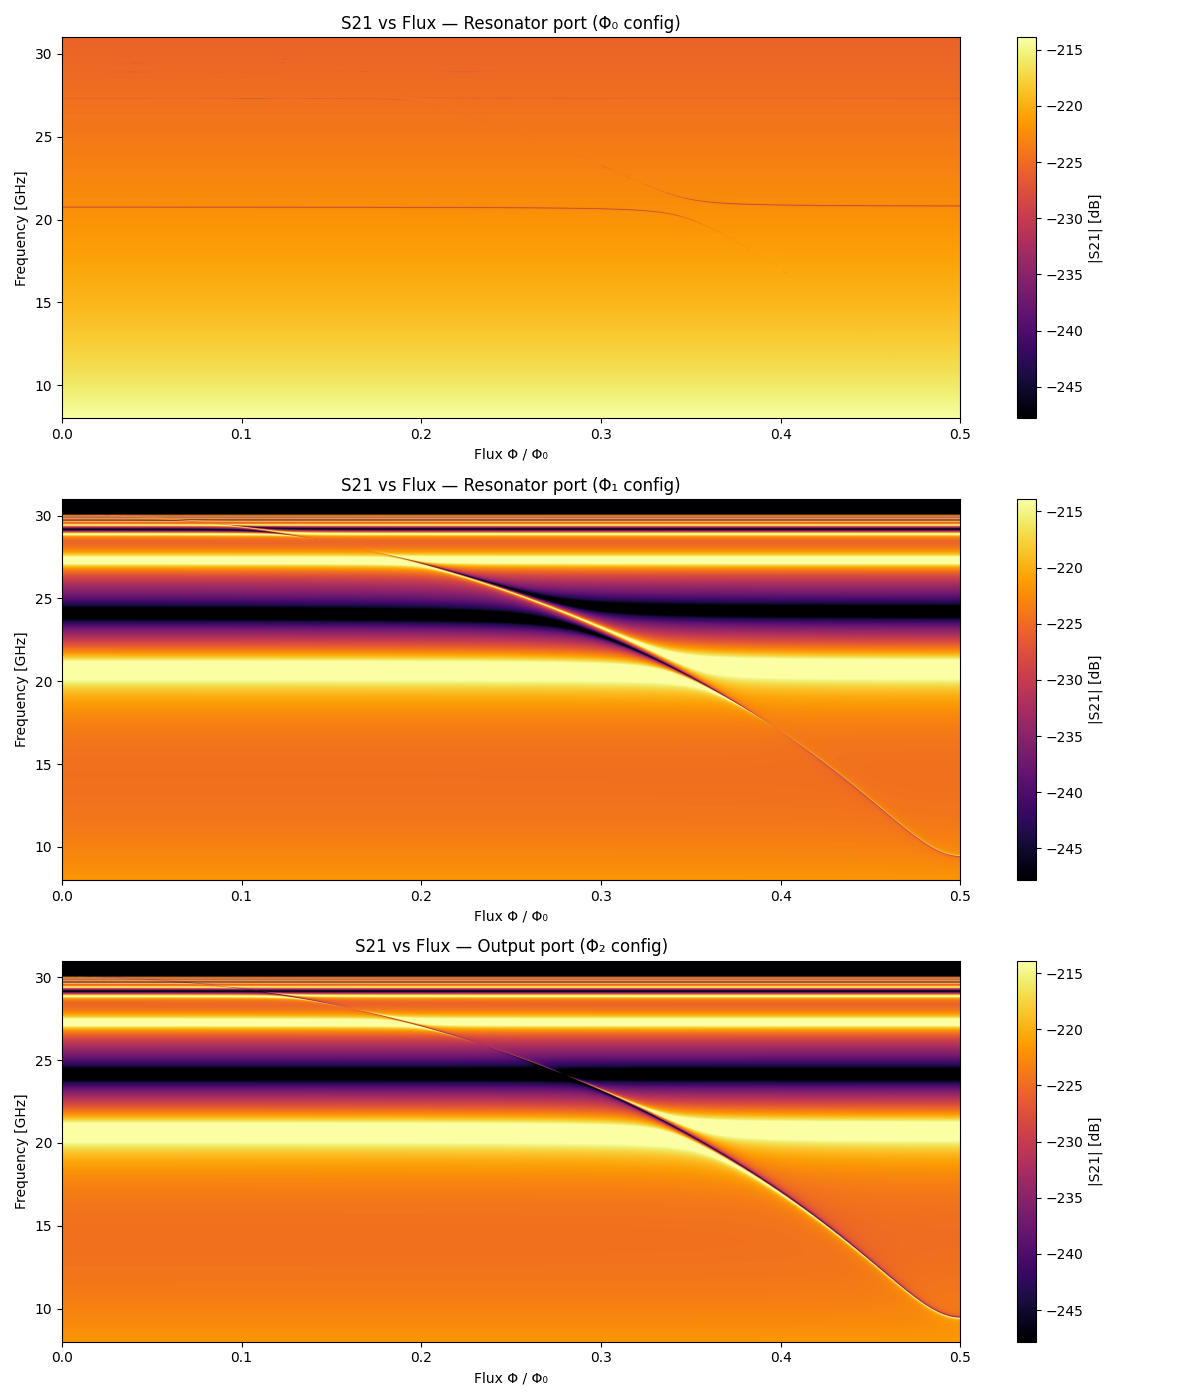

In [ ]:
###############################################################################
# NORMALIZATION SETTINGS
###############################################################################
# Choose: "global_minmax", "percentile_clip", "relative_norm"
norm_mode = "percentile_clip"

# Dynamic range compression (dB)
clip_low  = None#-60   # values below this are flattened
clip_high = None#0     # or leave None to auto-adjust

###############################################################################
# PREPARE DATA (convert to dB)
###############################################################################
S21_dB0 = 20*np.log10(np.abs(S_phi0))
S21_dB1 = 20*np.log10(np.abs(S_phi1))
S21_dB2 = 20*np.log10(np.abs(S_phi2))

all_maps = np.concatenate([S21_dB0.flatten(),
                           S21_dB1.flatten(),
                           S21_dB2.flatten()])

if norm_mode == "global_minmax":
    vmin = np.nanmin(all_maps)
    vmax = np.nanmax(all_maps)

elif norm_mode == "percentile_clip":
    # Smooth background + punchy S21 features
    vmin = np.percentile(all_maps, 5)
    vmax = np.percentile(all_maps, 95)

elif norm_mode == "relative_norm":
    # Each subplot uses its own scale
    vmin = vmax = None

# Optional: override using clip settings
if clip_low is not None:
    vmin = clip_low
if clip_high is not None:
    vmax = clip_high

###############################################################################
# PLOTTER
###############################################################################
plt.figure(figsize=(12, 14))

extent = [Phi_list[0]/Phi0, Phi_list[-1]/Phi0, f_span[0]/1e9, f_span[-1]/1e9]
titles = [
    "S21 vs Flux — Resonator port (Φ₀ config)",
    "S21 vs Flux — Resonator port (Φ₁ config)",
    "S21 vs Flux — Output port (Φ₂ config)"
]
maps = [S21_dB0, S21_dB1, S21_dB2]

for i, (Smap, title) in enumerate(zip(maps, titles)):
    ax = plt.subplot(3, 1, i+1)

    if norm_mode == "relative_norm":
        local_vmin = np.percentile(Smap, 5)
        local_vmax = np.percentile(Smap, 95)
    else:
        local_vmin = vmin
        local_vmax = vmax

    im = ax.imshow(
        Smap.T,
        aspect='auto',
        origin='lower',
        extent=extent,
        cmap='inferno',  # much better contrast than viridis
        vmin=local_vmin,
        vmax=local_vmax
    )

    plt.colorbar(im, ax=ax, label='|S21| [dB]')
    ax.set_ylabel("Frequency [GHz]")
    ax.set_xlabel("Flux Φ / Φ₀")
    ax.set_title(title)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import datetime

# ----------------------------------------------------------
# Data to save
# ----------------------------------------------------------
# S_phi0, S_phi1, S_phi2  → your S21 arrays
# f_span, flux_span      → frequency & flux axes
# Cc                     → coupling capacitor

# ----------------------------------------------------------
# Generate unique suffix with timestamp + Cc value (fF)
# ----------------------------------------------------------
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
Cc_fF = Cc * 1e15        # convert to fF for human-readable naming
suffix = f"_{timestamp}_Cc{Cc_fF:.1f}fF"

# ----------------------------------------------------------
# Save all arrays
# ----------------------------------------------------------
np.save(f"S_phi0{suffix}.npy", S_phi0)
np.save(f"S_phi1{suffix}.npy", S_phi1)
np.save(f"S_phi2{suffix}.npy", S_phi2)

np.save(f"f_span{suffix}.npy", f_span)
np.save(f"Phi_list{suffix}.npy", Phi_list)

print("Saved with suffix:", suffix)


Saved with suffix: _20251202_195048_Cc1.5fF


In [ ]:
import numpy as np

# ----------------------------------------------------------
# Insert the suffix printed when saving
# Example:
# suffix = "_20251202_193044_Cc1.5fF"
# ----------------------------------------------------------
suffix = "_20251202_193243_Cc1.5fF"

# ----------------------------------------------------------
# Load all arrays
# ----------------------------------------------------------
S_phi0 = np.load(f"S_phi0{suffix}.npy")
S_phi1 = np.load(f"S_phi1{suffix}.npy")
S_phi2 = np.load(f"S_phi2{suffix}.npy")

f_span = np.load(f"f_span{suffix}.npy")
Phi_list = np.load(f"Phi_list{suffix}.npy")

print("Loaded datasets for suffix:", suffix)


Loaded datasets for suffix: _20251202_193243_Cc1.5fF
